In [46]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read data: LA TripAdvisor Reviews
reviews = pd.read_csv('datasets/lasvegas_tripadvisor.csv')

# Intro to categorical plots using Seaborn

In [3]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   User country       504 non-null    str  
 1   Nr. reviews        504 non-null    int64
 2   Nr. hotel reviews  504 non-null    int64
 3   Helpful votes      504 non-null    int64
 4   Score              504 non-null    int64
 5   Period of stay     504 non-null    str  
 6   Traveler type      504 non-null    str  
 7   Pool               504 non-null    str  
 8   Gym                504 non-null    str  
 9   Tennis court       504 non-null    str  
 10  Spa                504 non-null    str  
 11  Casino             504 non-null    str  
 12  Free internet      504 non-null    str  
 13  Hotel name         504 non-null    str  
 14  Hotel stars        504 non-null    int64
 15  Nr. rooms          504 non-null    int64
 16  User continent     504 non-null    str  
 17  Member years       504 non-

## The catplot function
Parameters
- `x`, `y`: name of corresponding variables in `data`
- `data`: DataFrame being used
- `kind`: Type of plot. Options are strip, swarm, box, violin, boxen, point, bar, or count

Adjust font size, plot background, others, using `sns.set` and `sns.set_style`

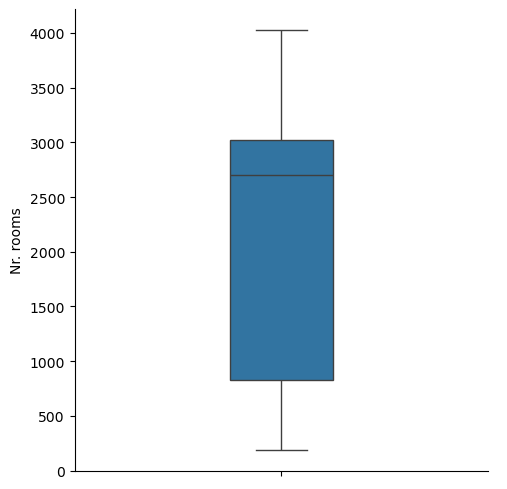

In [17]:
sns.catplot(data=reviews, y="Nr. rooms", kind="box", width=0.25)
plt.show()

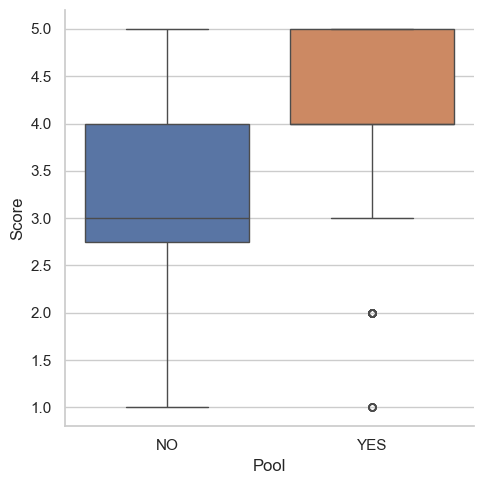

In [27]:
sns.catplot(data=reviews, x="Pool", y="Score", kind='box', hue="Pool")
sns.set(font_scale=1.4)
sns.set_style("whitegrid")
plt.show()

# Seaborn bar plots
- Basically the same as box plots, just with `kind='bar'`

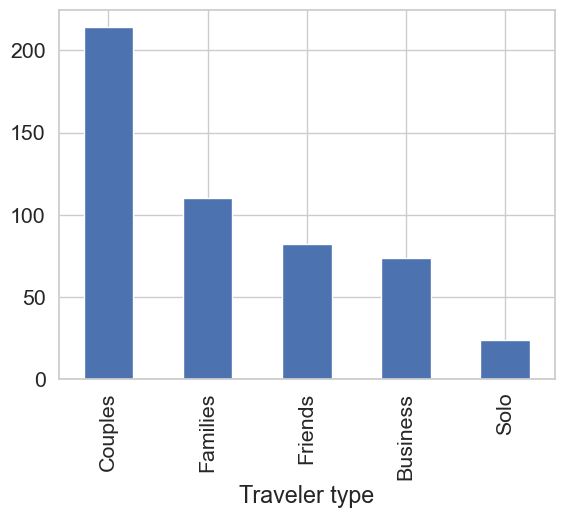

In [31]:
# Ex. of a typical bar chart
reviews["Traveler type"].value_counts().plot.bar() # Note, this is done using pandas built-in viz tools (pd.DF.plot()), not seaborn
plt.show()

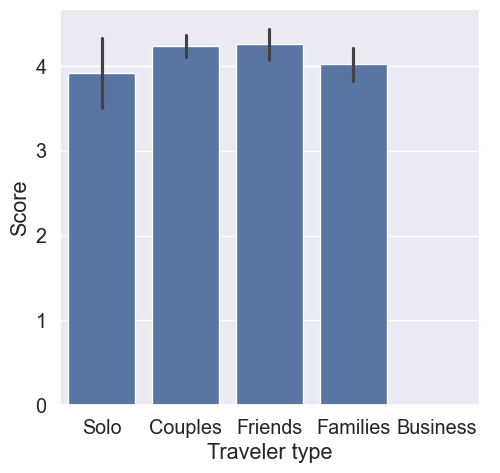

In [ ]:
sns.set(font_scale=1.3)
sns.set_style("darkgrid")
sns.catplot(x="Traveler type", y="Score", data=reviews, kind="bar")
plt.show()

## Ordering your categories
- use `df['col'].astype("category")` -> Defaults to alphabetical order
- Alternatively, use `order` param in `catplot()`, but not all viz methods have this
- Best practice to specify order *outside of catplot()* so that all visualizations follow the intended order
- use ` df['col'].cat.reorder_categories() ` to reorder...?

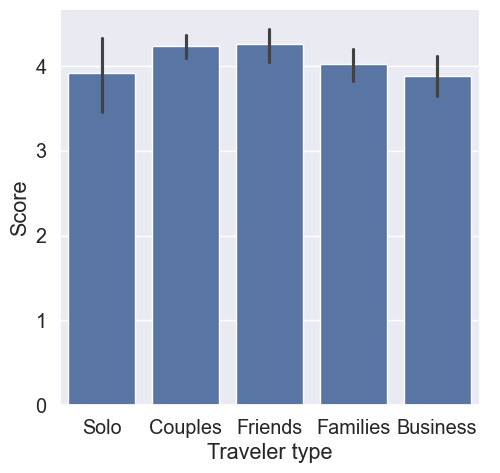

In [47]:
reviews["Traveler type"] = reviews["Traveler type"].astype('category')
reviews["Traveler type"] = reviews["Traveler type"].cat.set_categories(
    new_categories = ["Solo", "Couples", "Friends", "Families", "Business"],
    ordered= True
)
sns.catplot(x="Traveler type", y="Score", data=reviews, kind="bar")
plt.show()

## Splitting again with the hue parameter
- Use hue to split each x category into sub-categories

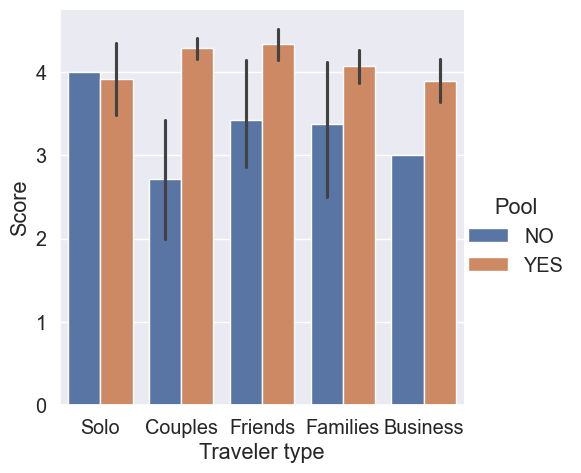

In [48]:
sns.catplot(x="Traveler type", y="Score", data = reviews, kind = "bar", hue = "Pool")
plt.show()

- Huh. There's a huge disparity in average ratings based on presence of a pool *specifically for couples*. No CI for business/no and solo/no makes the result there uncertain. Not enough data?

### Luke Note: Use the least powerful tool
- ex. Should you use `Series.cat.set_categories()` or `Series.cat.reorder_categories()` when the result would be the same?
- `reorder_categories` is the "least powerful tool". Don't use a chainsaw when a handsaw would do.
    - More powerful -> more room for mistakes and errors
- Readability -> using `reorder_categories()` makes the purpose immediately clear to a reader of the code. Using `set_categories` implies that you're creating *new* categories, when you're actually just trying to reorder it.
- Safety -> using `reorder_categories()` would actually crash if the there was a missing value, whereas `set_categories` would produce NaN values. Here, a crash is actually desirable, because it indicates that *something is wrong* in a way that could otherwise be easily missed. 

# Point and count plots
- Point plot and bar plot are very similar when using only one categorical variable
- `dodge=True` parameter adds space between lines to avoid visual overlapping
- `join=False` removes the line connecting points
    - This is deprecated. Use `linestyle='none'` instead

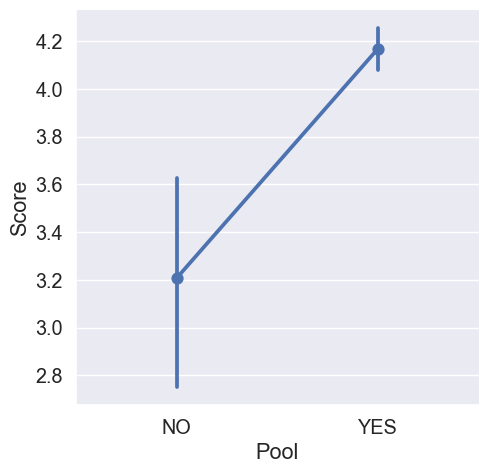

In [49]:
sns.catplot(x="Pool", y="Score", data=reviews, kind="point")
plt.show()

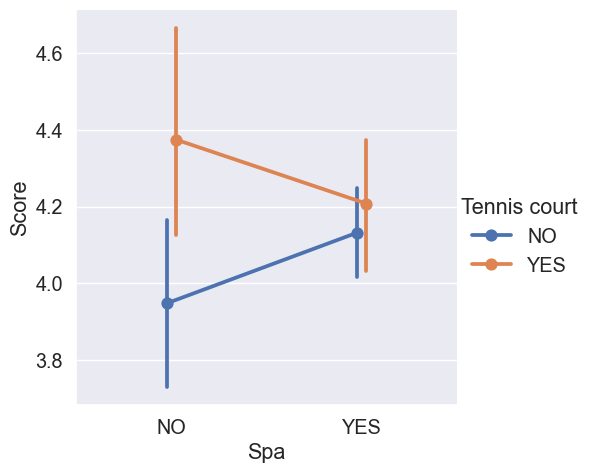

In [53]:
sns.catplot(x="Spa", y="Score", data=reviews, kind="point", hue="Tennis court",dodge=True)
plt.show()

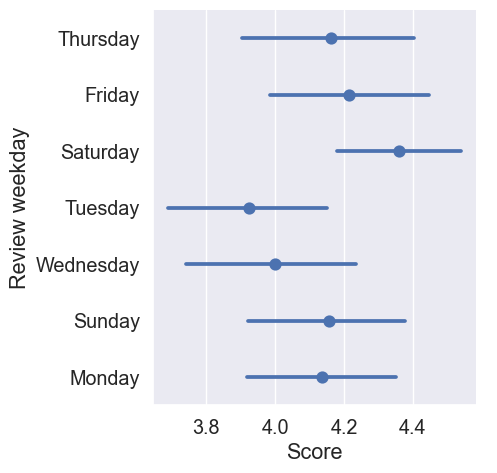

In [57]:
sns.catplot(x="Score",
            y="Review weekday",
            data=reviews,
            kind="point",
            #join=False <- Deprecated
            linestyle="none"
)
plt.show()

## One last catplot type
- `kind = 'count'`
- Visually looks similar to barplot, but the difference is the y-axis.
    - countplots have *count* as the y-axis (or frequency)
    - barplots have a quantitative variable as the y-axis

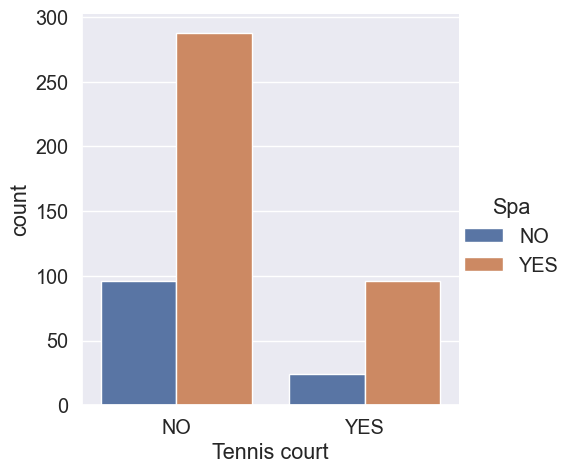

In [59]:
sns.catplot(x="Tennis court", data=reviews, kind="count", hue="Spa")
plt.show()

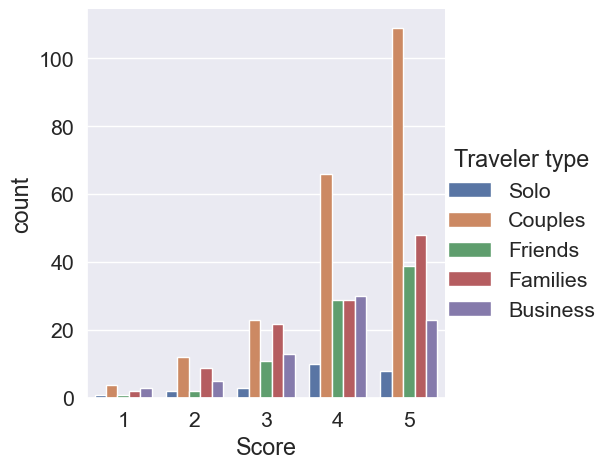

In [60]:
sns.set(font_scale=1.4)
sns.set_style("darkgrid")

# Create a catplot that will count the frequency of "Score" across "Traveler type"
sns.catplot(
  x = "Score",
  hue = "Traveler type",
  data = reviews,
  kind='count'
)
plt.show()

- Data question: Is there a difference in average score based on Traveler type? Particularly, do couples give higher scores on average?
- Which 

# Additional catplot() options
- `col` and `col_wrap` for creating subplots
- `palette = sns.color_palette()` for changing palette
    - PITA. Use `    hue = "Traveler type",
    palette = sns.set_palette("Set1"),
    dodge = False`

## Using the catplot() facetgrid to create multiple plots simultaneously
- use the `col` argument to create a catplot for each value
- use `col_wrap` to indicate the number of plots per row (ex. `col_wrap = 3` means the visualization "wraps" after every 3rd graphic)

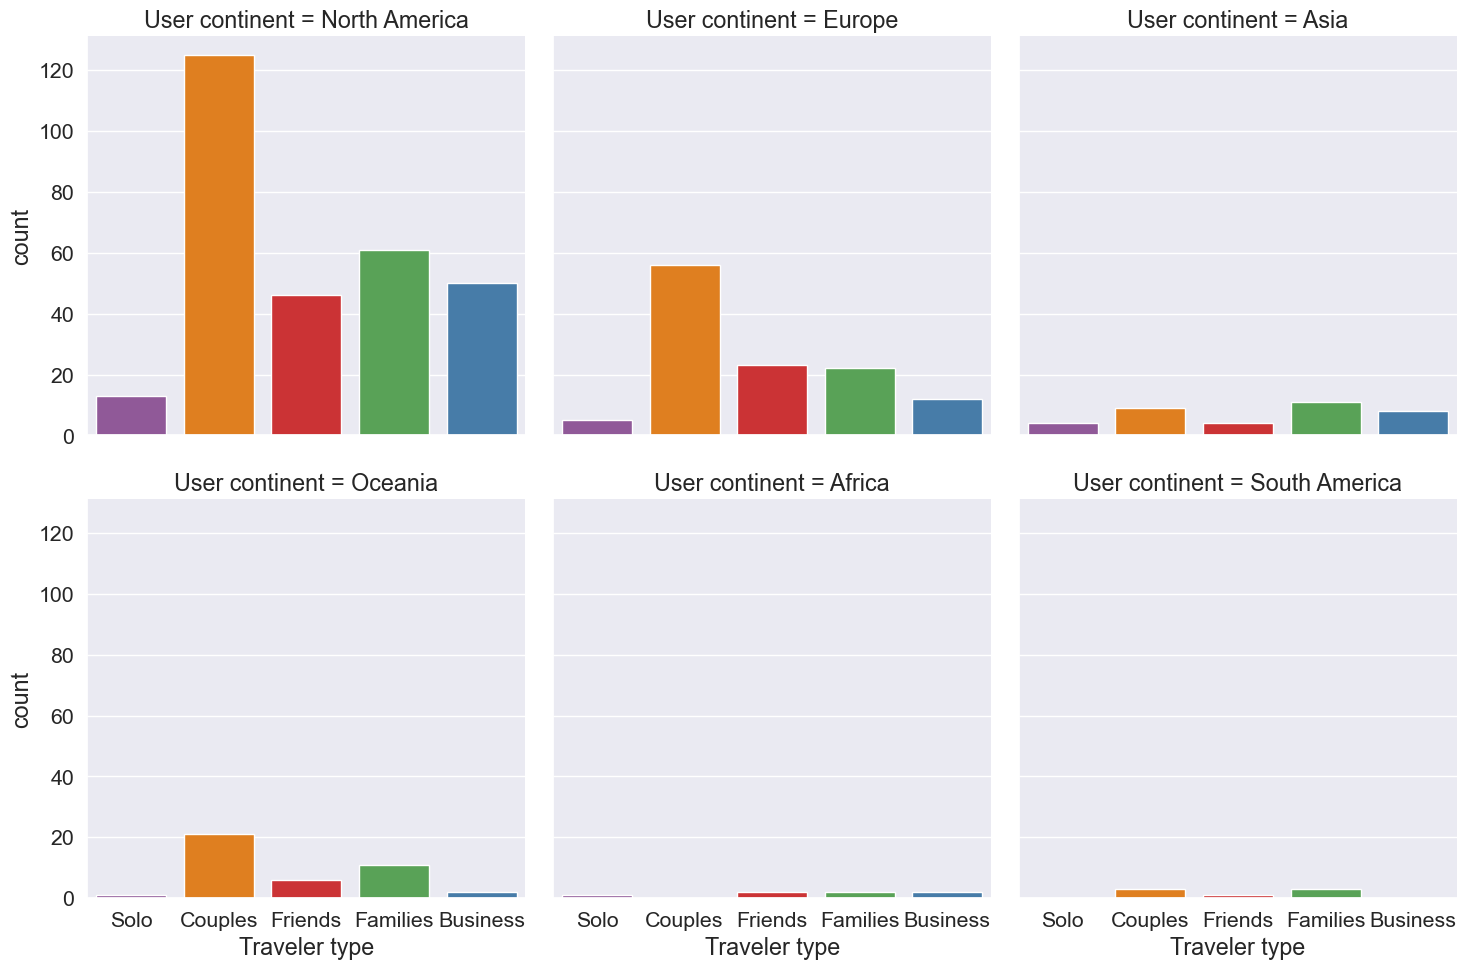

In [80]:
sns.catplot(
    x="Traveler type",
    kind = "count",
    col = "User continent",
    col_wrap = 3,
    data=reviews,
    hue = "Traveler type",
    palette = sns.set_palette("Set1"),
    dodge = False
)
plt.show()

## Updating plots
- Save seaborn graphic as an axes object (ax)
- Add plot titles, axis labels, and adjust title height.
    - `ax.fig.suptitle("")`
    - `ax.set_axis_labels("x-label", "y-label")`
    - `plt.subplots(top = .9)`

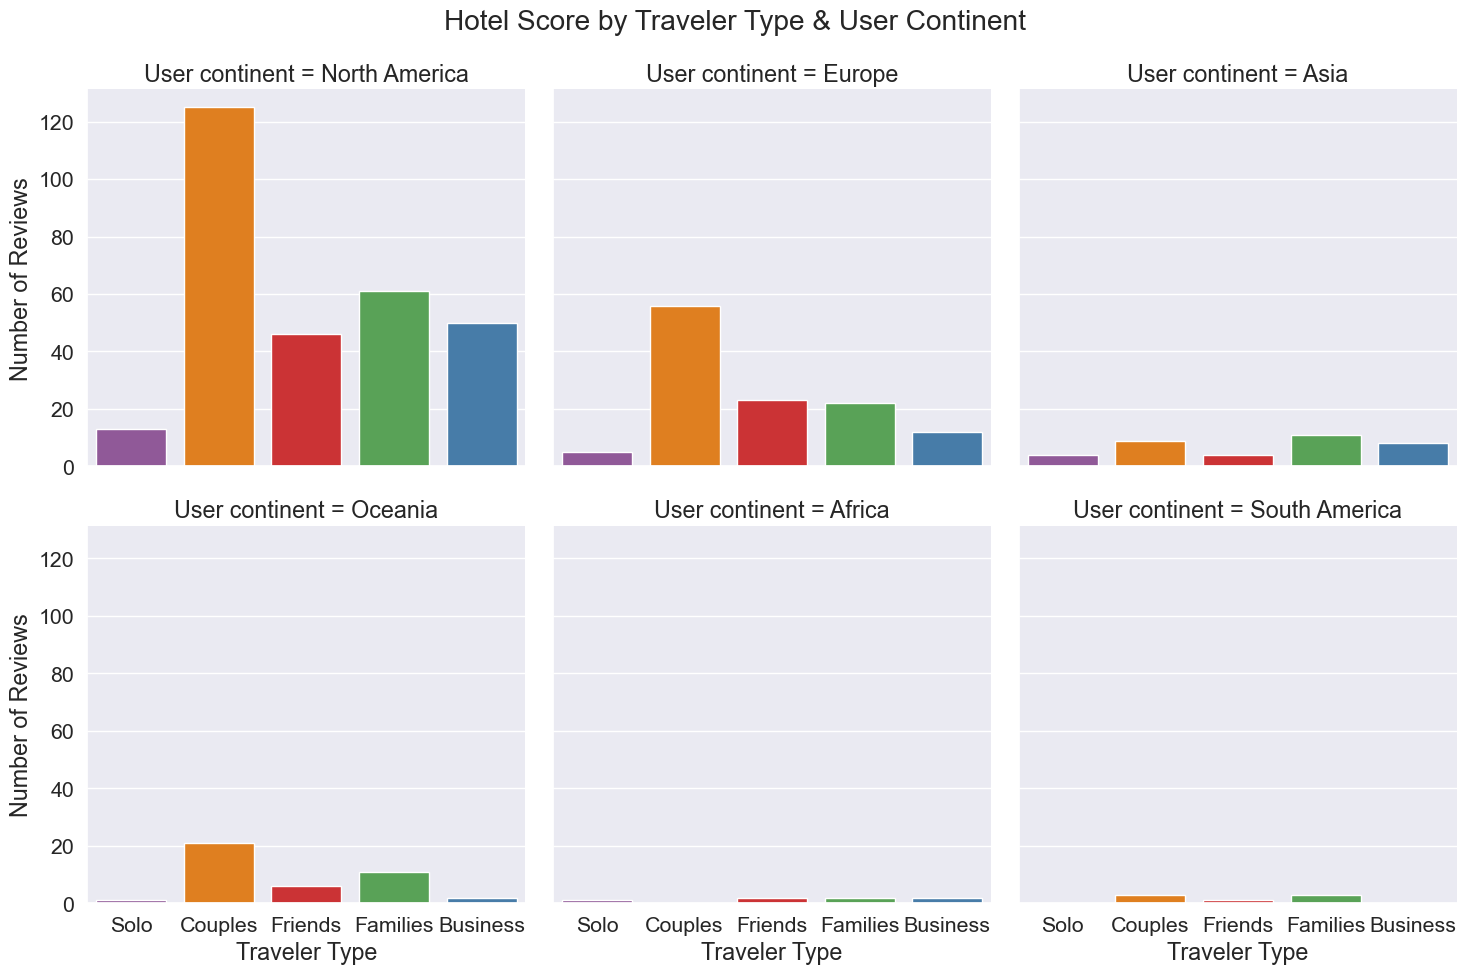

In [83]:
ax = sns.catplot(
    x= "Traveler type",
    col = "User continent",
    col_wrap = 3,
    kind = "count",
    hue = "Traveler type",
    palette = sns.set_palette("Set1"),
    dodge = False,
    data = reviews
)
ax.fig.suptitle("Hotel Score by Traveler Type & User Continent")
ax.set_axis_labels("Traveler Type", "Number of Reviews")
plt.subplots_adjust(top=.9)
plt.show()